### Print raw data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [16]:
x = '/Users/arthu/Documents/Marseille/aMU/M1/Stage/data/ACP/Export_pupille_ACP_13_M_58ANS_Bensons1_2024-06-21_14-38-16.csv'
df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1')

In [4]:
def extract_windows(data):
    stim_windows = []
    stim_on = np.where(data.iloc[:, 9]=='croix centrale=off')[0]+1
    for i in stim_on:
        stim_off = np.where(data.iloc[i: i+1805, 9]=='consignes=on')[0][0]-1
        stim_windows.append((i, i+stim_off))
    return stim_windows

In [5]:
stim_windows = extract_windows(df)

In [ ]:
## plot a specific window
fig, ax = plt.subplots(8, figsize=(7, 15))

stim = stim_windows[0]

for i, ax in enumerate(ax):
    x = np.linspace(stim[0]/300, stim[1]/300, len(df.iloc[stim[0]: stim[1], i+1]))
    ax.set_ylabel(df.columns.values[i+1])
    ax.set_xlabel('Time (sec)')
    ax.plot(x, df.iloc[stim[0]: stim[1], i+1])
    # ax.hlines(np.mean(df.iloc[stim[0]: stim[1], i+1]), xmin=stim[0], xmax=stim[1], color='r', alpha=0.5)
    # ax.hlines(np.mean(df.iloc[stim[0]: stim[1], i+1])/1.5, xmin=stim[0], xmax=stim[1], color='black', alpha=0.7)
    
plt.tight_layout()

### Detect and remove eye blinks

In [7]:
## detect eye blink
def detect_blink(data, sampling_rate=300, ms2add=60):
    '''
    --- Parameters ---
    data: all data streams from a time window
    '''
    
    # Set threshold (threshold is set at: mean - 1.5*mean)
  
    series = data[:, 5] # RDX channel is used because eye blinks are the most clear in this channel
    mean = np.mean(series)/1.5
    
    # extract blink windows
    blink_windows = []

    blink_duration_extension = int(sampling_rate / 1000 * ms2add)
    
    # extract points that cross the threshold
    blink = []
    for i in range(len(series)-1):
        if series[i]<=mean:
            blink.append(i)
            if series[i+1]>mean:
                blink_windows.append((blink[0], blink[-1]))
                blink = []
    
    # extract time window
    for i in range(len(blink_windows)):
        mid = (blink_windows[i][1] - blink_windows[i][0])//2 + blink_windows[i][1]
        blink_windows[i] = (mid-blink_duration_extension, mid+blink_duration_extension)

    return blink_windows

In [22]:
## remove eye blinks
def remove_blink(data, blink_windows):
    data = data.astype(float)

    for i in range(len(data.T)):
        series = data[:, i]
        for j in blink_windows:
            series[j[0]: j[1]] = np.nan

    return data

In [23]:
## remove eye blinks
def remove_blink_padding(data, blink_windows):
    data = data.astype(float)
    
    for i in range(len(data.T)):
        series = data[:, i]
        for j in blink_windows:
            series[j[0]-15: j[1]+15] = np.nan
    
    nan_proportion = np.sum(np.isnan(data[:, 0]))/len(data[:, 0])

    if nan_proportion > 0.3:
        data[:, :] = np.nan
        return data
    else:
        return data

In [24]:
# The following function was adapted from Sina Kling's eyeprep repository
# URL: https://github.com/sinaklg/eyeprep
# Retrieved on: June 2, 2026

def interpol_nans(eyetracking_data):
    """
    Interpolate missing (NaN) values in eye-tracking data, filling gaps with the nearest valid data.

    Args:
        eyetracking_data (np.array): Eye-tracking data containing NaN values.

    Returns:
        np.array: Interpolated data with NaNs replaced.
    """
    
    nan_indices = np.isnan(eyetracking_data)

    # Fill NaNs at the start and end with nearest valid values
    if nan_indices[0]:  # If the first value is NaN
        first_valid_idx = np.where(~nan_indices)[0][0]
        eyetracking_data[:first_valid_idx] = eyetracking_data[first_valid_idx]
        
    if nan_indices[-1]:  # If the last value is NaN
        last_valid_idx = np.where(~nan_indices)[0][-1]
        eyetracking_data[last_valid_idx+1:] = eyetracking_data[last_valid_idx]

    # Now interpolate remaining NaNs
    eyetracking_no_nans = np.nan_to_num(eyetracking_data)
    eyetracking_signal_interpolated = np.interp(np.arange(len(eyetracking_data)),
                                               np.where(~nan_indices)[0],
                                               eyetracking_no_nans[~nan_indices])
    
    return eyetracking_signal_interpolated

In [25]:
raw_data = np.array(df.iloc[:, 1:9])

for v in stim_windows:
    blinks = detect_blink(raw_data[v[0]:v[1], :])
    if blinks:
        raw_data[v[0]:v[1], :] = remove_blink_padding(raw_data[v[0]:v[1], :], blinks)
        for i in range(len(raw_data.T)):
            raw_data[v[0]:v[1], i] = interpol_nans(raw_data[v[0]:v[1], i])

pupil_diam = pd.DataFrame(raw_data[:, 4:8], columns=df.iloc[:, 5:9].columns.values) ## only keeps the pupil diam

In [26]:
order_stim = []
for stim in stim_windows:
    a = df.loc[stim[0], 'Label'].split('_')
    order_stim.append((a[1], a[2]))

AttributeError: 'float' object has no attribute 'split'

In [27]:
pupil_diam['category'] = None
pupil_diam['valence'] = None
pupil_diam['trial'] = None
pupil_diam['time'] = None

In [28]:
x = np.linspace(0, 1792/300, 1792)

for i, v in enumerate(stim_windows):
    pupil_diam.loc[v[0]:v[1], 'category'] = order_stim[i][0]
    pupil_diam.loc[v[0]:v[1], 'valence'] = order_stim[i][1]
    pupil_diam.loc[v[0]:v[0]+1791, 'trial'] = i
    for j in range(1792):
        pupil_diam.loc[v[0]+j, 'time'] = x[j]

IndexError: list index out of range

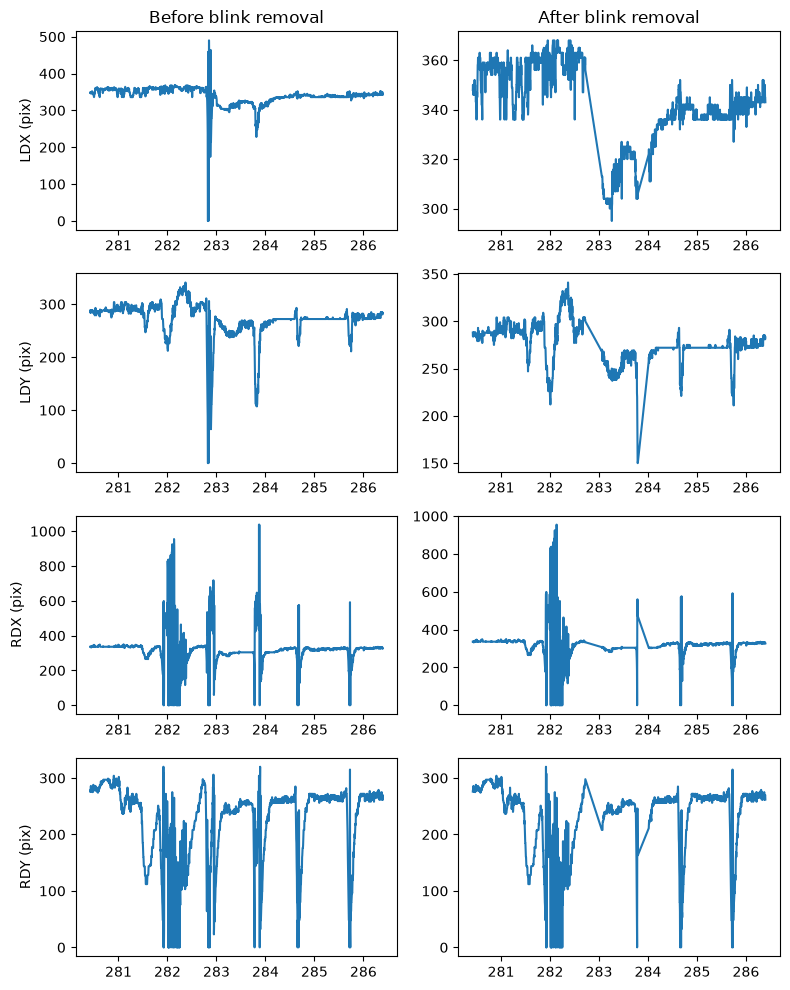

In [29]:
# plot timeseries before and after blink removal

fig, ax = plt.subplots(4, 2, figsize=(8, 10))
# issues: 10 (didn't detect), 17 (too many blinks)
stim = stim_windows[11]
x = np.linspace(stim[0]/300, stim[1]/300, len(pupil_diam.iloc[stim[0]: stim[1], 0]))

for i, axes in enumerate(ax):
    axes[0].set_ylabel(pupil_diam.columns.values[i])
    axes[0].plot(x, df.iloc[stim[0]: stim[1], i+5])
    axes[1].plot(x, pupil_diam.iloc[stim[0]: stim[1], i])

ax[0, 0].set_title("Before blink removal")
ax[0, 1].set_title("After blink removal")

plt.tight_layout()

### Smooth data

In [26]:
def smooth(data, stim_windows, column, freq):
    for col in column:
        sos = sp.signal.butter(5, Wn=freq, fs=300, btype='low', output='sos')
        data.loc[:, col] = sp.signal.sosfiltfilt(sos, data.loc[:, col])
    return data

pupil_diam = smooth(pupil_diam, stim_windows, list(pupil_diam.columns.values)[0:4], freq=15)

### Test different methods for identifying eye blinks

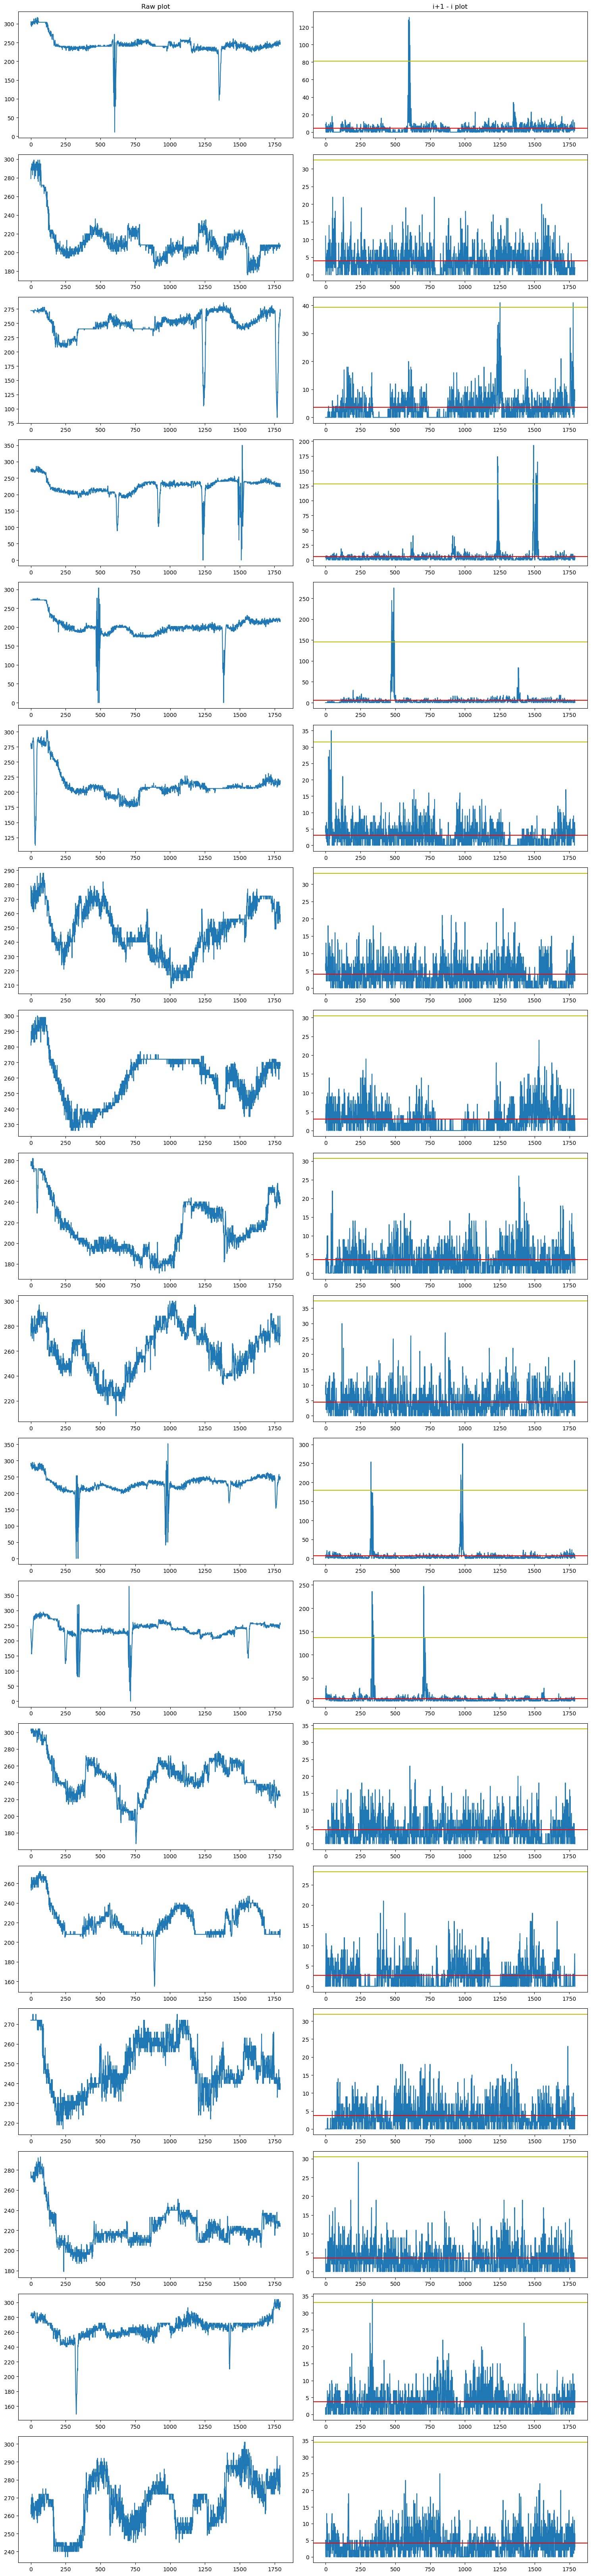

In [13]:
# 1. plot the difference between i and i+1 (function np.diff does this)
test1_data = np.array(df.iloc[:, 8])
fig, ax = plt.subplots(18, 2, figsize=(15, 65))

for i, stim in enumerate(stim_windows):
    d = []
    points = test1_data[stim[0]:stim[1]]
    for j in range(len(points)-1):
        d.append(np.abs(points[j+1]-points[j]))
    ax[i][0].plot(points)
    ax[i][1].plot(d)
    ax[i][1].axhline(np.mean(d), xmin=0, xmax = len(points), color='r')
    ax[i][1].axhline(np.std(d)*9, xmin=0, xmax = len(points), color='y')

ax[0][0].set_title('Raw plot')
ax[0][1].set_title('i+1 - i plot')


plt.tight_layout()

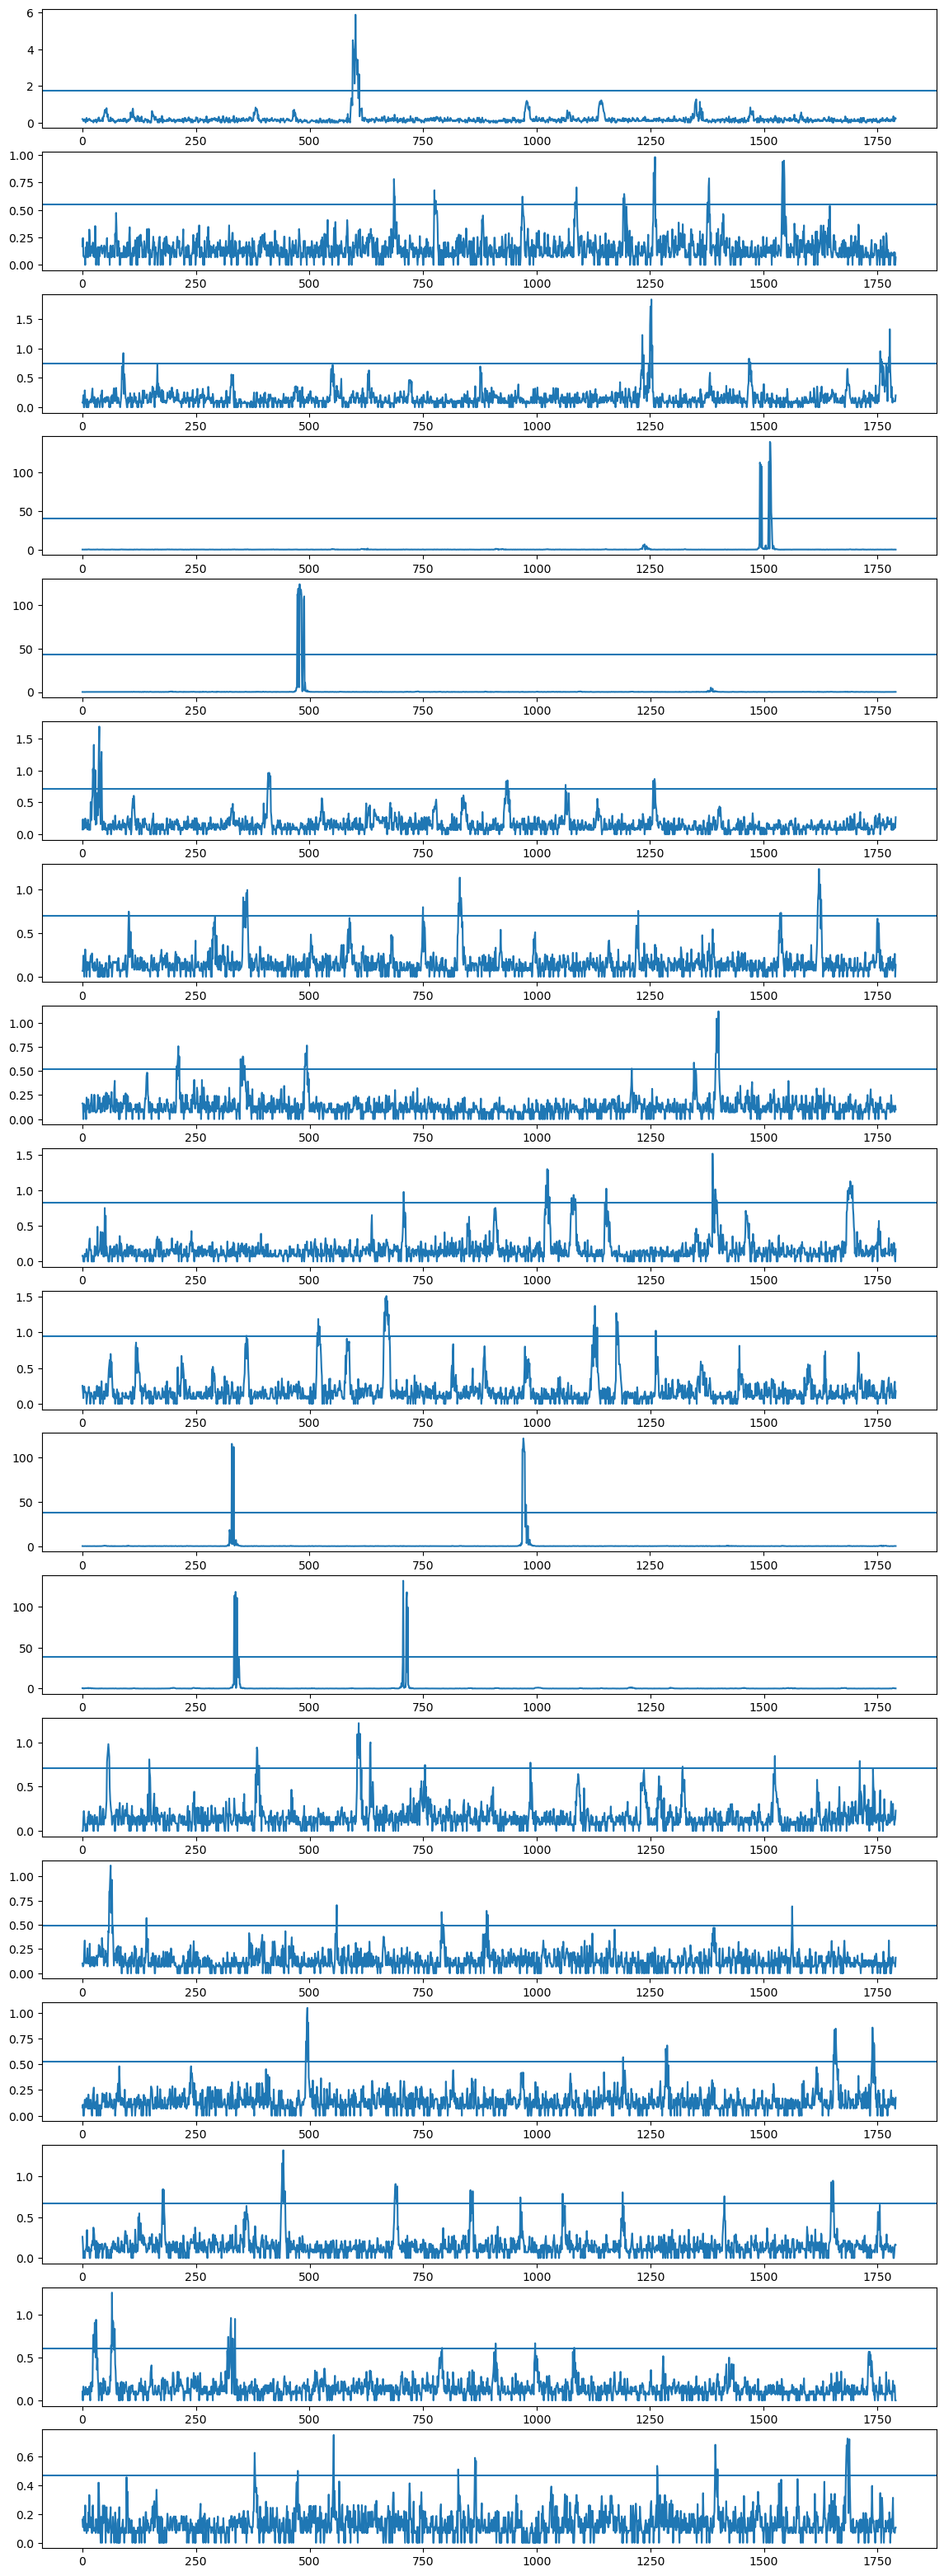

In [14]:
# 2. calculate eye velocity
x_pos = np.array(df.iloc[:, 3])
y_pos = np.array(df.iloc[:, 4])

velocity = []
dt = 1

for stim in stim_windows:
    x = x_pos[stim[0]:stim[1]]
    y = y_pos[stim[0]:stim[1]]
    v = []
    for i in range(len(x)-1):
        v.append(np.sqrt(((x[i+1] - x[i])**2)+((y[i+1] - y[i])**2))/dt)
    velocity.append(v)

fig, ax = plt.subplots(18, figsize=(14,40))

for i, v in enumerate(velocity):
    ax[i].plot(v)
    ax[i].axhline(np.std(v)*5, xmin=0, xmax=len(v))

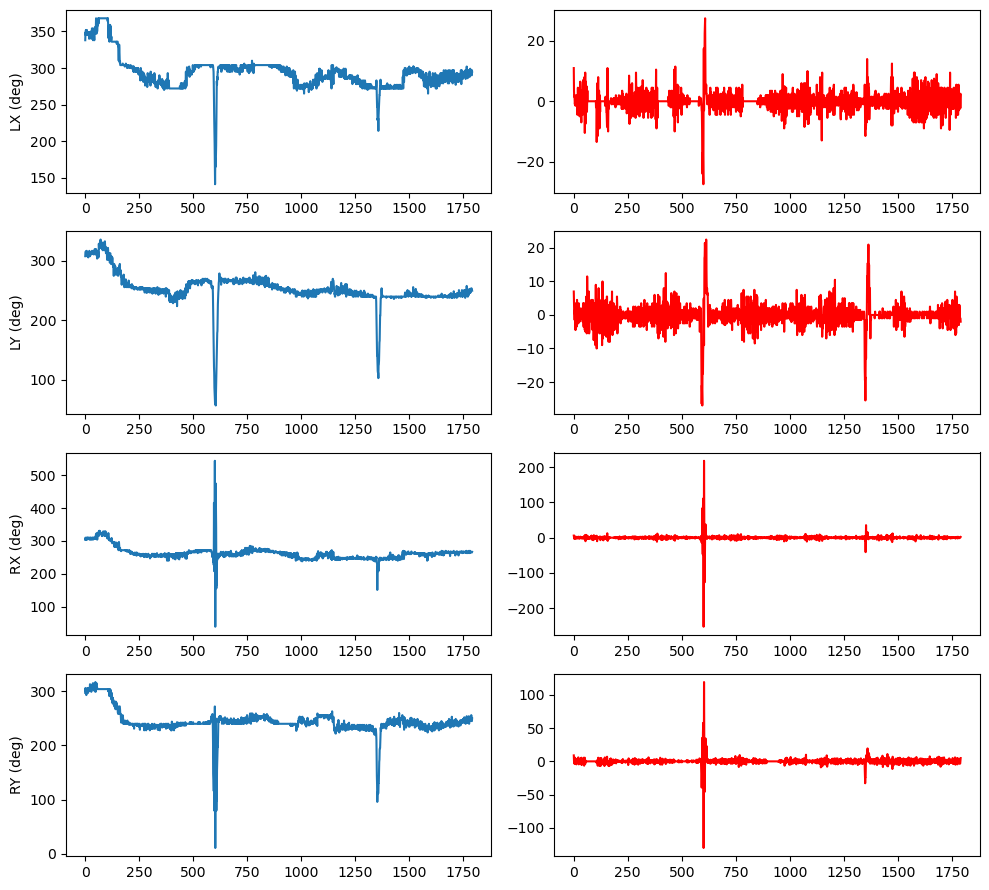

In [15]:
# 3. plot gradient of raw plot
stim = stim_windows[0]
test3_data = np.array(df.iloc[stim[0]: stim[1], 5:9])

fig, ax = plt.subplots(4, 2, figsize=(10, 9))

for i, ax in enumerate(ax):
    ax[0].set_ylabel(df.columns.values[i+1])
    ax[0].plot(test3_data[:, i])
    ax[1].plot(np.gradient(test3_data[:, i]), color='r')

plt.tight_layout()

### Plot eye co-ordinates on image and screen

In [10]:
from PIL import Image

In [11]:
img = Image.open('../Data/Stim/Benson_bloc_1/15_visage_neutre_2512_eq.bmp')

In [12]:
# eye_coordinates_deg = np.array(df.iloc[stim_windows[14][0]: stim_windows[14][1], 1:5])

In [20]:
eye_coordinates_deg = df.loc[stim_windows[14][0]:stim_windows[14][1], ['LX (deg)', 'LY (deg)', 'RX (deg)', 'RY (deg)']]

In [24]:
def deg2pix(deg, screen_distance, screen_size, resolution):
    rad = (deg*np.pi)/180
    screen_pos_mm = np.tan(rad)*screen_distance

    x_convert = resolution[0]/screen_size[0]
    y_convert = resolution[1]/screen_size[1]

    screen_pos_mm.iloc[:, 0] *= x_convert
    screen_pos_mm.iloc[:, 1] *= y_convert

    if len(deg.T) == 4:
        screen_pos_mm.iloc[:, 2] *= x_convert
        screen_pos_mm.iloc[:, 3] *= y_convert

    return screen_pos_mm

In [25]:
screen_distance_mm = 600
screen_size_mm = [478, 269]
resolution = [1920, 1080]

eye_coordinates_pix = deg2pix(eye_coordinates_deg, screen_distance_mm, screen_size_mm, resolution)

In [26]:
eye_coordinates_pix

,LX (deg),LY (deg),RX (deg),RY (deg)
84500,196.235993,-48.356656,-95.744022,-47.893991
84501,193.484014,-45.033961,-95.575505,-44.487206
84502,190.393926,-48.482838,-92.879347,-48.146353
84503,193.611017,-41.627326,-92.879347,-48.146353
84504,190.563230,-45.076020,-92.879347,-48.146353
...,...,...,...,...
86288,265.475051,15.304083,-75.317571,12.066620
86289,265.389904,11.856396,-78.391305,8.871244
86290,265.389904,11.856396,-81.254739,9.165553
86291,265.389904,11.856396,-78.012338,15.808628


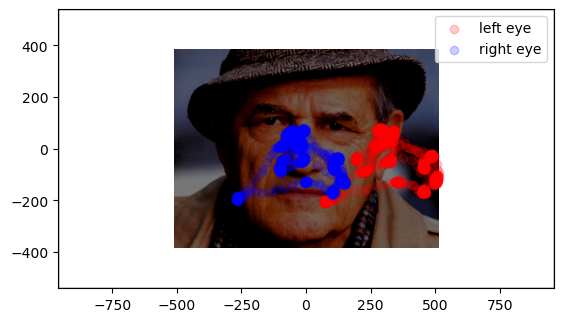

In [28]:
fig, ax = plt.subplots()

img_width = 1024
img_height = 768

rect_width = 1920
rect_height = 1080
img_x = rect_width / 2
img_y = rect_height / 2

ax.imshow(img, extent=[-img_width/2, img_width/2, -img_height/2, img_height/2])

rectangle = plt.Rectangle((-1920/2, -1080/2), rect_width, rect_height, fill=False)
ax.add_patch(rectangle)
ax.set_xlim(-1920/2, 1920/2)
ax.set_ylim(-1080/2, 1080/2)

plt.scatter(eye_coordinates_pix.loc[:, 'LX (deg)'], eye_coordinates_pix.loc[:, 'LY (deg)'], color='r', alpha=0.2, label="left eye")
if len(eye_coordinates_pix.T) == 4:
    plt.scatter(eye_coordinates_pix.loc[:, 'RX (deg)'], eye_coordinates_pix.loc[:, 'RY (deg)'], color='b', alpha=0.2, label="right eye")

plt.legend()
plt.show()

### Baseline correction

In [28]:
def baseline_correct(data, stim_windows, column):
    for col in column:
        for v in stim_windows:
            mean = np.mean(data.loc[v[0]-60:v[0], col])
            data.loc[v[0]:v[1], col] = data.loc[v[0]:v[1], col]-mean

    return data

pupil_diam = baseline_correct(pupil_diam, stim_windows, list(pupil_diam.columns.values)[0:4])

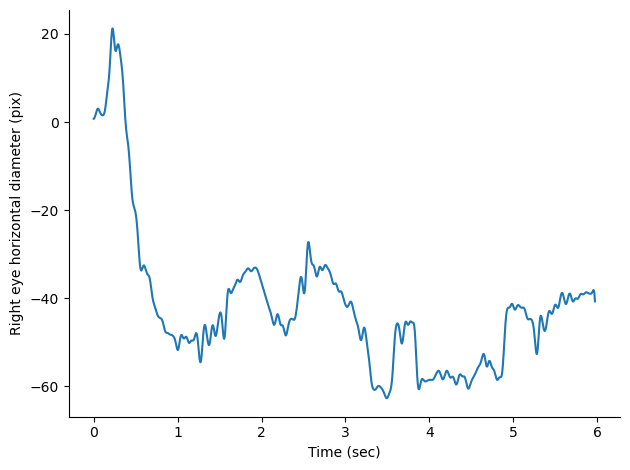

In [30]:
x = np.linspace(0, (stim_windows[0][1]-stim_windows[0][0])/300, stim_windows[0][1]-stim_windows[0][0])
ax = sns.lineplot(data=pupil_diam.iloc[stim_windows[0][0]:stim_windows[0][1]], x=x, y='RDX (pix)')
sns.despine()
ax.set(xlabel='Time (sec)', ylabel='Right eye horizontal diameter (pix)')
plt.tight_layout()

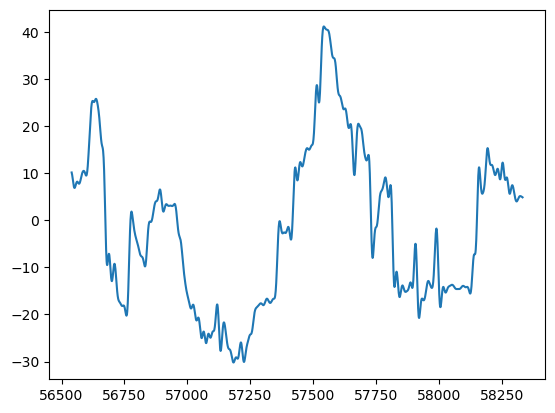

In [29]:
plt.plot(pupil_diam.loc[stim_windows[9][0]:stim_windows[9][1], 'LDY (pix)'])

### Remove bad signals
- Method is to remove signals whose average corrected signal is above 0

In [51]:
bad = []

for i, v in enumerate(stim_windows):
    if np.mean(pupil_diam.loc[v[0]:v[1], 'RDX (pix)']) > 0:
        pupil_diam.loc[v[0]:v[1], 'RDX (pix)'] = np.nan
        bad.append(i)

In [84]:
pupil_diam = pupil_diam.dropna(axis=0)

### Compare pupil diameter for different emotional valence and category
- Will only look at right eye channels for now since the left eye channels have more device related artifacts

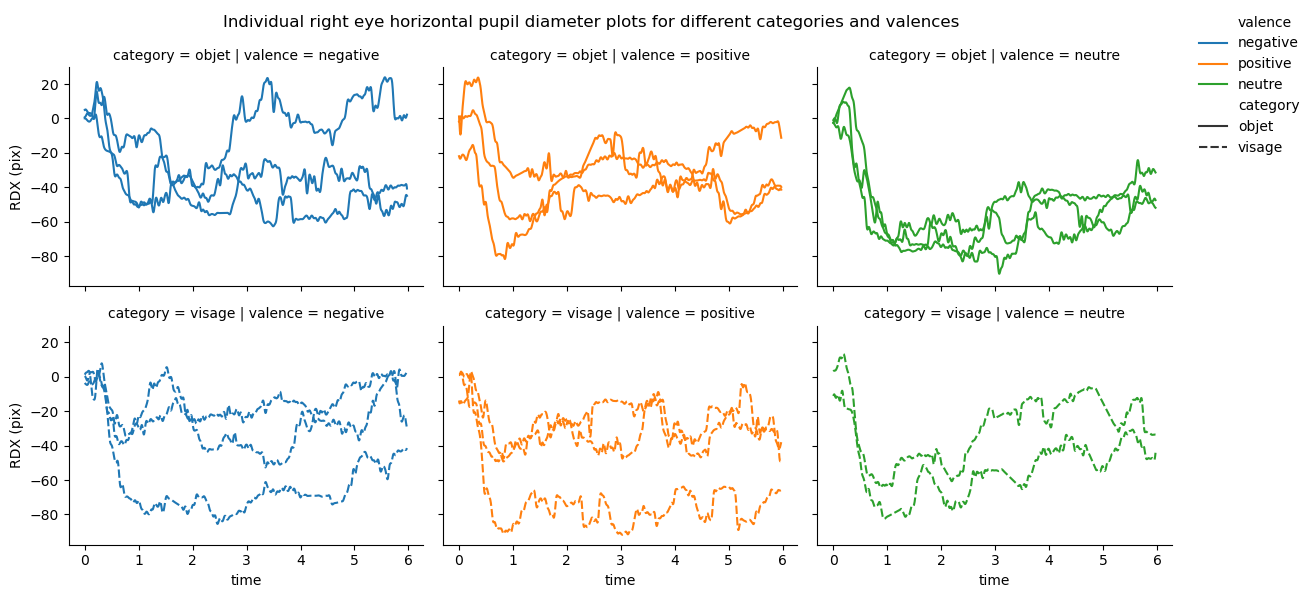

In [134]:
ax = sns.relplot(
    data=pupil_diam,
    x='time', y='RDX (pix)',
    col='valence', row='category', 
    hue='valence', style='category',
    units='trial', estimator=None,
    kind='line', errorbar=None,
    height=3, aspect=1.2
)

ax.fig.suptitle('Individual right eye horizontal pupil diameter plots for different categories and valences')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

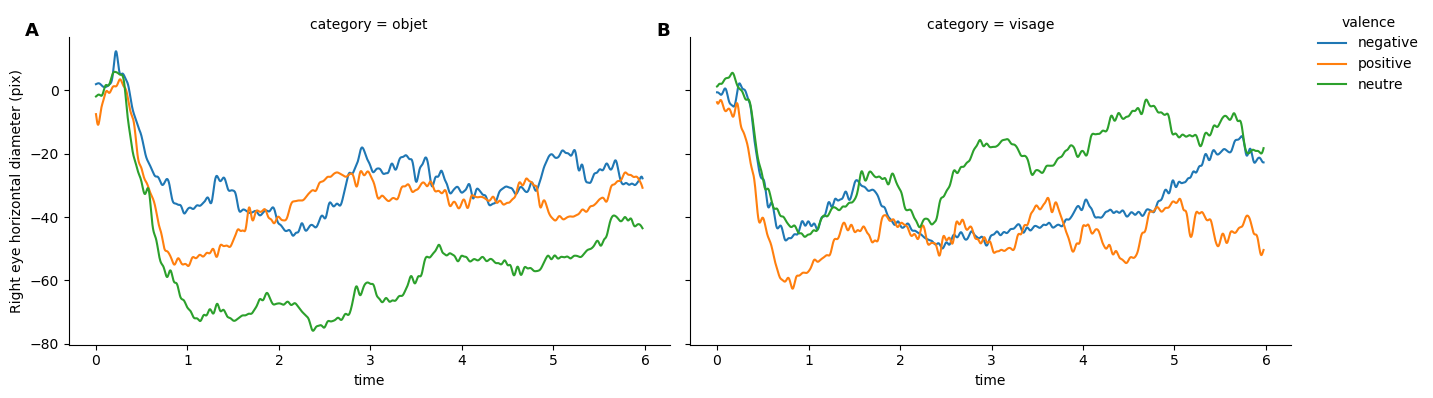

In [63]:
p1 = sns.relplot(
    data=pupil_diam,
    x='time', y='RDX (pix)', hue='valence',
    col='category', col_wrap=2,
    kind='line', errorbar=None,
    height=4, aspect=1.5
)

ax = p1.axes[0]



ax.text(-0.05, 1.05, 'A', transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
ax.text(1.00, 1.05, 'B', transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
# ax.fig.suptitle('Average right eye horizontal pupil diameter for different categories and valences')
sns.move_legend(p1, "upper left", bbox_to_anchor=(1, 1))
p1.set(ylabel='Right eye horizontal diameter (pix)')
plt.tight_layout()

In [51]:
ax.fig.text?

Signature: ax.fig.text(x, y, s, fontdict=None, **kwargs)
Docstring:
Add text to figure.

Parameters
----------
x, y : float
    The position to place the text. By default, this is in figure
    coordinates, floats in [0, 1]. The coordinate system can be changed
    using the *transform* keyword.

s : str
    The text string.

fontdict : dict, optional
    A dictionary to override the default text properties. If not given,
    the defaults are determined by :rc:`font.*`. Properties passed as
    *kwargs* override the corresponding ones given in *fontdict*.

Returns
-------
`~.text.Text`

Other Parameters
----------------
**kwargs : `~matplotlib.text.Text` properties
    Other miscellaneous text parameters.

    Properties:
    agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
    alpha: scalar or None
    animated: bool
    antialiased: bool
    backgroundcolor: :mplt

### Plot average pupil diameter for each emotional valence stimuli

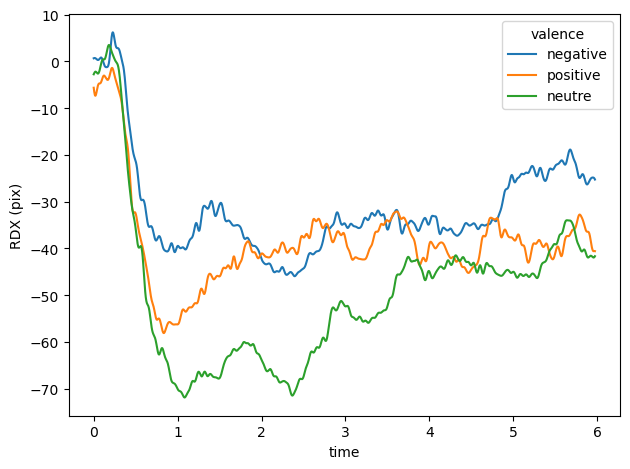

In [135]:
sns.lineplot(data=pupil_diam, x='time', y='RDX (pix)', hue='valence', errorbar=None)

ax.fig.suptitle('Average right eye horizontal pupil diameter for different valences')
plt.tight_layout()

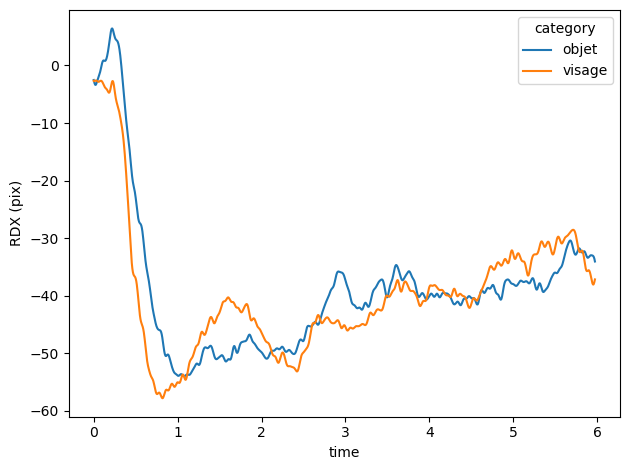

In [136]:
sns.lineplot(data=pupil_diam, x='time', y='RDX (pix)', hue='category', errorbar=None)

ax.fig.suptitle('Average right eye horizontal pupil diameter for different categories')
plt.tight_layout()

### Testing DataMatrix for preprocessing
- https://github.com/open-cogsci/datamatrix/tree/1.0

In [30]:
import datamatrix._datamatrix._blinkreconstruct as br
from datamatrix import DataMatrix, SeriesColumn, series as srs
from datamatrix import convert

In [52]:
order_stim = []
for stim in stim_windows:
    order_stim.append(df.iloc[stim[0], -2].split('_')[1])

In [53]:
data = {
    "type": order_stim,
    "emotional_valence": order_emotion,
    "pupil_dilation": pupil_d_rdx
}

df_rdx = pd.DataFrame(data)

NameError: name 'pupil_d_rdx' is not defined

In [ ]:
# initialise DataMatrix
dm = convert.from_pandas(df_rdx.iloc[:,0:2])
# added series columns
dm.signal = SeriesColumn(depth=1792)
# set the time plot for each series
for i, stim in enumerate(stim_windows):
     dm.signal[i]=df.iloc[stim[0]:stim[0]+1792, 7]

In [ ]:
fig, ax = plt.subplots(18, 3, figsize=(20, 40))

pupil_rdx_datamatrix = []

for i, axes in enumerate(ax):
    no_blink = br._blinkreconstruct_recursive(dm.signal[i], vt_start=1.9, vt_end=0)
    no_blink = interpol_nans(no_blink)
    pupil_rdx_datamatrix.append(no_blink)
    axes[0].plot(dm.signal[i])
    axes[1].plot(no_blink)
    axes[2].plot(pupil_d_rdx[i])

ax[0][0].set_title('Raw')
ax[0][1].set_title('DataMatrix')
ax[0][2].set_title('My method')

plt.tight_layout()

In [38]:
neg_ave, neu_ave, pos_ave = mean_emotion(pupil_rdx_datamatrix, order_emotion)

plt.plot(time_axis, neg_ave*conversion, label='Negative')
plt.plot(time_axis, neu_ave*conversion, label='Neutral')
plt.plot(time_axis, pos_ave*conversion, label='Positive')

plt.xlabel('Time (seconds)')
plt.ylabel('Pupil Diameter (mm)')


plt.title('DataMatrix: average horizontal pupil diameter across the three emotional valence stimuli')
plt.tight_layout()
plt.legend()
plt.show()

NameError: name 'mean_emotion' is not defined

### Test data quality

<Axes: xlabel='time', ylabel='RDX (pix)'>

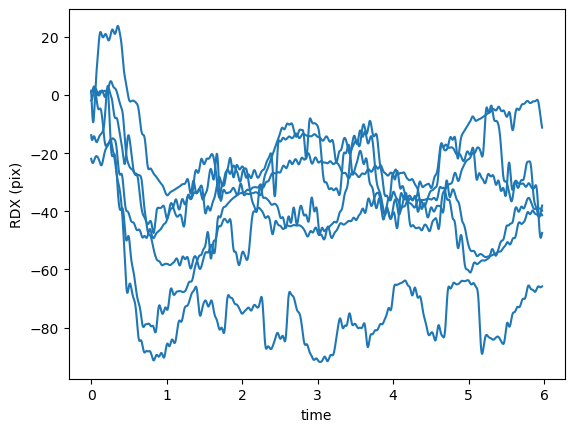

In [64]:
sns.lineplot(data=pupil_diam[pupil_diam['valence']=='positive'], x='time', y='RDX (pix)', units='trial', estimator=None, errorbar=None)

### Feature extraction

In [38]:
from sklearn.metrics import auc

In [39]:
def features(data, time):
    '''
    Extract features (features taken from Emotional valence through pupil: Machine learning classification under controlled visual complexity and emotional arousal in young adults paper)
    '''
    features = {
        'max': max(data),
        'min': min(data),
        'mean': np.mean(data),
        'std': np.std(data),
        'start_pupil_size': data[0], # pupil size at time 0
        'end_pupil_size': data[-1], # ending pupil size
        'peak_after_drop': max(data[300:]), # maximum pupil size after the initial drop
        'peak_ratio': min(data)/max(data), # ratio of minimum to maximum pupil size
        'peak_latency': np.where(data==max(data))[0][0], # time to reach max pupil size
        'drop_latency': np.where(data==min(data))[0][0], # time to reach minimum pupil size
        'drop_ratio': min(data)/data[0], # ratio of minimum pupil size to initial pupil size
        'recovery_ratio': data[-1]/data[0], # final pupil size to initial pupil size
        'response_duration': (np.where(data==max(data))[0] - np.where(data==min(data))[0])[0], # difference between time to reach max pupil size and min pupil size
        'reaction_extent': min(data)/data[0] + data[-1]/data[0], # sum of the ratio of min and final pupil size with initial pupil size
        'recovery_gradient': (neg_ave[-1]-min(neg_ave[:350]))/(len(neg_ave)-np.where(neg_ave==min(neg_ave[:350]))[0][0]), # gradient of curve after the initial drop
        'stability': np.mean(data)/np.std(data),
        'range': max(data)-min(data),
        'baseline_deviation': data[0] - np.mean(data),
        'AUPC': auc(time, data)
    }
    return features

In [40]:
neg_features = features(neg_ave, time_axis)
neu_features = features(neu_ave, time_axis)
pos_features = features(pos_ave, time_axis)

### Testing path

In [31]:
from pathlib import Path

In [32]:
current_dir = Path.cwd()

In [33]:
project_dir = current_dir.parent.parent

In [30]:
ACP_dir = project_dir / "data/ACP"

# Mathematical model
### $D(t)=D_0-D_1*\delta_{t\geq t_0}*(\frac{t-t_0}{\tau_1})*e^{-\frac{t-t_0}{\tau_2}}$
- $D_0$: baseline pupil diameter
- $\delta$: Kronecker delta
- $t_0$: latency period
- $\tau_1$: decay factor: smaller $\tau_1$, greater decay (pupil constriction)
- $\tau_2$: recovery factor: smaller $\tau_2$, earlier and faster recovery (pupil dilation)

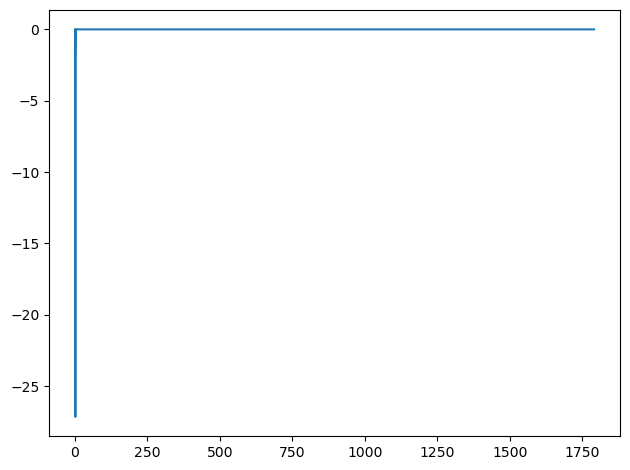

In [44]:
# initial parameters
D_0 = 0
D_1 = 260
t_0 = 0.3
dt = 0.001
tau_1 = 0.65
tau_2 = 0.30


def sim_func(D_0, D_1, t_0, tau_1, tau_2):
    D = []
    for t in range(1792):
        delta = 1
        if t < t_0:
            delta = 0
        D.append(D_0 - D_1*delta*((t-t_0)/tau_1)*np.exp(-((t-t_0)/tau_2)))
    return D
    

a = sim_func(D_0, D_1, t_0, tau_1, tau_2)
plt.plot(a)
plt.tight_layout()

### Model fitting

In [36]:
## vectorise

def sim_func_vect(D_0, D_1, t_0, tau_1, tau_2):
    t = np.linspace(0, 1792/300, 1792)
    delta = np.where(t < t_0, 0, 1)
    
    D = D_0 - D_1*delta*((t-t_0)/tau_1)*np.exp(-((t-t_0)/tau_2))
    return D

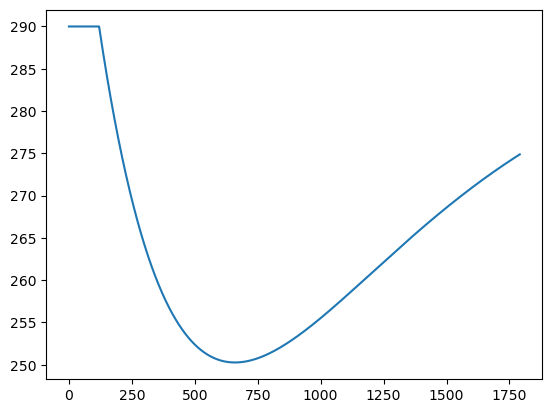

In [37]:
t = np.linspace(0, 1792/300, 1792)
D = sim_func_vect(290, 150.0, 0.4, 2.5, 1.8)

plt.plot(D)

In [48]:
from lmfit import Model
time_axis = np.linspace(0, 1792/300, 1792)
x = time_axis
y = neg_ave

gmodel = Model(sim_func_vect)
params = gmodel.make_params()

params['D_1'].set(value=150.0, min=0.05)
params['t_0'].set(value=0.1, min=0.0)
params['tau_1'].set(value=2.5, min=0)
params['tau_2'].set(value=1.8, min=0)

result = gmodel.fit(y, params, x=x, D_0=neg_ave[10])

print(result.fit_report())

plt.plot(x, y, 'o')
plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.legend()
plt.show()

NameError: name 'neg_ave' is not defined

In [356]:
## ToDo
vectorise sim_func using np
parametre de fit (maxeval et tolerance)
weights (more or less importance to different data points) -> weights=None
only set min not max
... fit log of parameter (maybe)
test left and right eye to confirm that the left eye is bad



gmodel.fit?

Signature:
gmodel.fit(
    data,
    params=None,
    weights=None,
    method='leastsq',
    iter_cb=None,
    scale_covar=True,
    verbose=False,
    fit_kws=None,
    nan_policy=None,
    calc_covar=True,
    max_nfev=None,
    coerce_farray=True,
    **kwargs,
)
Docstring:
Fit the model to the data using the supplied Parameters.

Parameters
----------
data : array_like
    Array of data to be fit.
params : Parameters, optional
    Parameters to use in fit (default is None).
weights : array_like, optional
    Weights to use for the calculation of the fit residual [i.e.,
    `weights*(data-fit)`]. Default is None; must have the same size as
    `data`.
method : str, optional
    Name of fitting method to use (default is `'leastsq'`).
iter_cb : callable, optional
    Callback function to call at each iteration (default is None).
scale_covar : bool, optional
    Whether to automatically scale the covariance matrix when
    calculating uncertainties (default is True).
verbose : bool, o

In [47]:
true_params = {}
for i in range(len(result.summary()['params'])):
    true_params[result.summary()['params'][i][0]] = result.summary()['params'][i][1]

In [48]:
result.best_values

{'D_1': 2.429270438970924,
 't_0': 17.91148788569035,
 'tau_1': 13.560385030231068,
 'tau_2': 654.0664938822576}

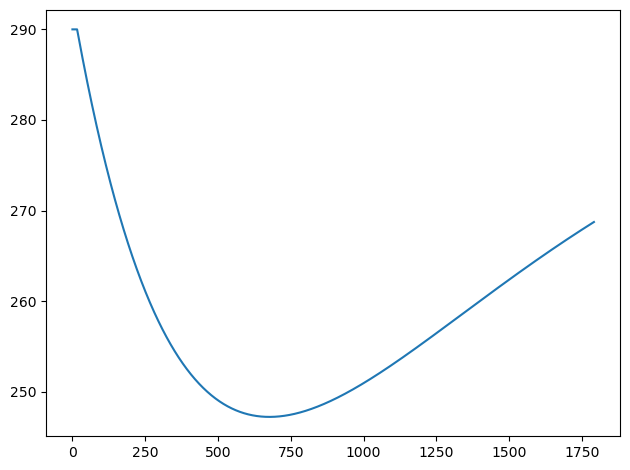

In [49]:
D_0 = 290
D_1 = 2.35909534
t_0 = 16.1498024
tau_1 = 13.3935471
tau_2 = 660.359197

a = np.array(sim_func(D_0, D_1, t_0, tau_1, tau_2))
plt.plot(a)
plt.tight_layout()

### Calculate MSE to identify bad traces

In [50]:
neg_idx = [i for i, x in enumerate(order_emotion) if x == "negative"]
neu_idx = [i for i, x in enumerate(order_emotion) if x == "neutre"]
pos_idx = [i for i, x in enumerate(order_emotion) if x == "positive"]

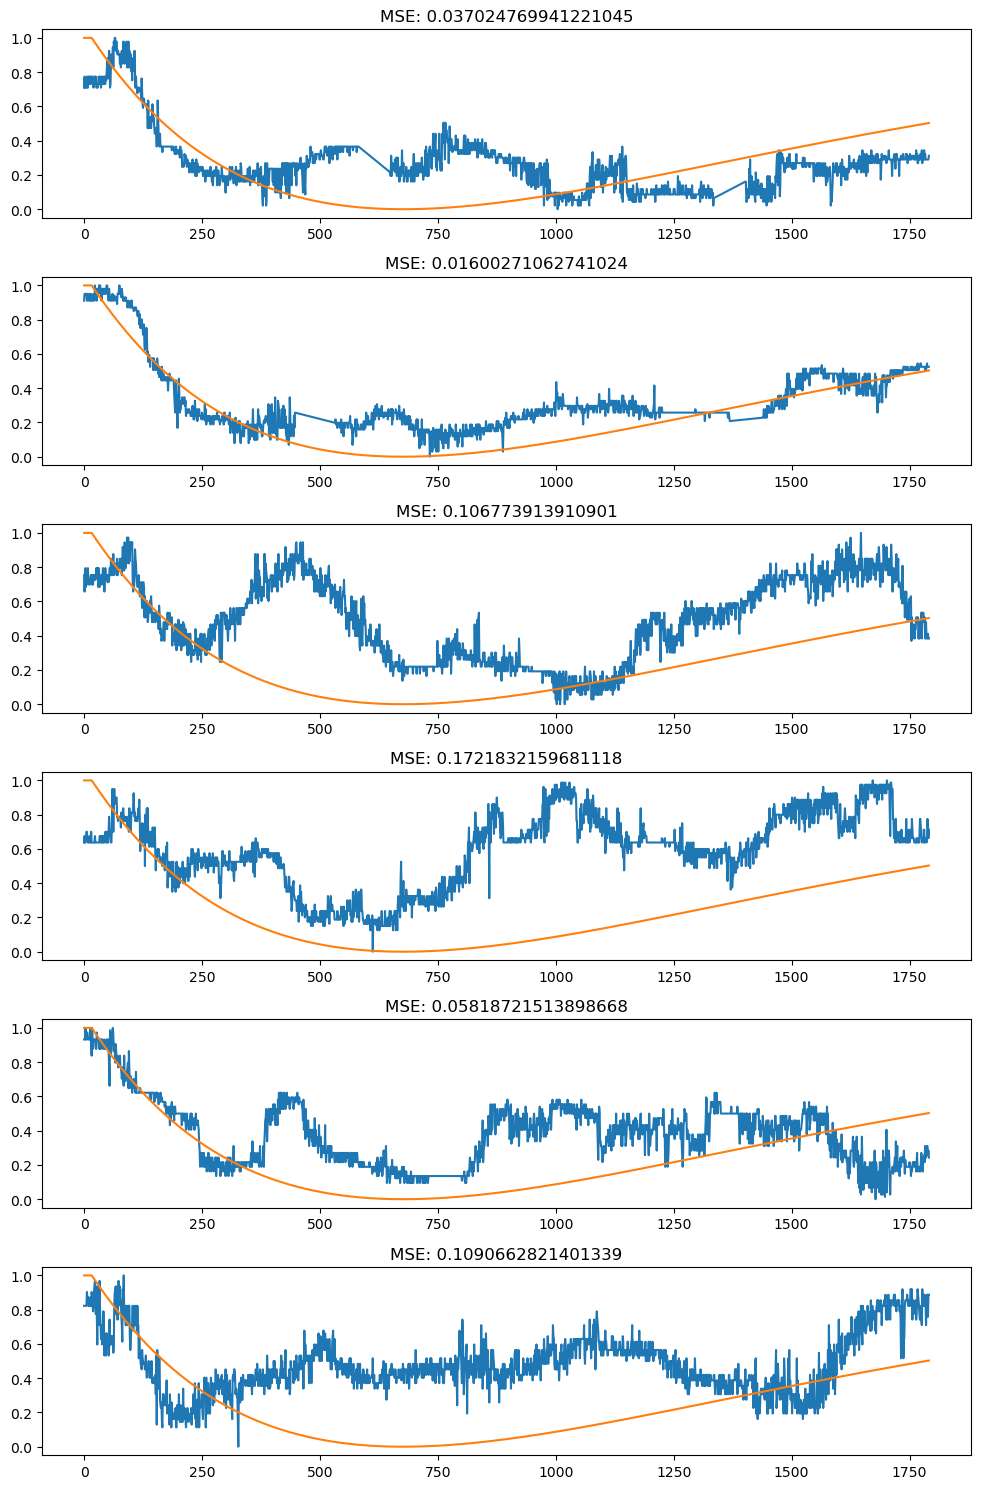

In [51]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import minmax_scale

fig, ax = plt.subplots(6, figsize=(10, 15))

for i, v in enumerate(neg_idx):
    real = minmax_scale(pupil_d_rdx[v])
    predict = minmax_scale(sim_func(pupil_d_rdx[v][10], D_1, t_0, tau_1, tau_2))
    ax[i].plot(real)
    ax[i].plot(predict)
    mse = mean_squared_error(real, predict)
    ax[i].set_title(f'MSE: {mse}')

plt.tight_layout()

### Extract parameters for each condition

In [23]:
from src.extract_windows import extract_window
from src.remove_eyeblinks import interpol_blinks
from src.extract_average import mean_emotion, order_emotion, pupil_area
from src.model_data import model_fit, remove_bad
from pandas.errors import EmptyDataError

In [44]:
def extract_params(file):
    negative_params = []
    neutral_params = []
    positive_params = []
    for i, x in enumerate(file.iterdir()):
        # import data
        print(f'starting {i}')
        try:
            df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1')
            window = extract_window(df)

            # remove and interpolate eye blinks
            data_no_blink = interpol_blinks(df.loc[:, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']], window)

            # detect emotion
            order = order_emotion(df.loc[:, 'Label'], window)
            # area = pupil_area(data_no_blink.loc[:, ['RDX (pix)', 'RDY (pix)']])
            neg, neu, pos = mean_emotion(data_no_blink.loc[:, 'RDX (pix)'], order, window)

            negative_params.append(model_fit(time_axis, neg))
            neutral_params.append(model_fit(time_axis, neu))
            positive_params.append(model_fit(time_axis, pos))
        except EmptyDataError:
            print(x)

    return negative_params, neutral_params, positive_params

In [ ]:
project_dir = Path.cwd().parent.parent
DFT_dir = project_dir / "data/DFT"
neg_param, neu_param, pos_param = extract_params(DFT_dir)

DFT_RDX_neg = pd.DataFrame(neg_param)
DFT_RDX_neg = DFT_RDX_neg.drop('length', axis=1)
DFT_RDX_neg['condition'] = 'DFT'
DFT_RDX_neg['valence'] = 'negative'

DFT_RDX_neu = pd.DataFrame(neu_param)
DFT_RDX_neu = DFT_RDX_neu.drop('length', axis=1)
DFT_RDX_neu['condition'] = 'DFT'
DFT_RDX_neu['valence'] = 'neutral'

DFT_RDX_pos = pd.DataFrame(pos_param)
DFT_RDX_pos = DFT_RDX_pos.drop('length', axis=1)
DFT_RDX_pos['condition'] = 'DFT'
DFT_RDX_pos['valence'] = 'positive'

In [ ]:
PCA_dir = project_dir / "data/ACP"
neg_param, neu_param, pos_param = extract_params(PCA_dir)

PCA_RDX_neg = pd.DataFrame(neg_param)
PCA_RDX_neg = PCA_RDX_neg.drop('length', axis=1)
PCA_RDX_neg['condition'] = 'PCA'
PCA_RDX_neg['valence'] = 'negative'

PCA_RDX_neu = pd.DataFrame(neu_param)
PCA_RDX_neu = PCA_RDX_neu.drop('length', axis=1)
PCA_RDX_neu['condition'] = 'PCA'
PCA_RDX_neu['valence'] = 'neutral'

PCA_RDX_pos = pd.DataFrame(pos_param)
PCA_RDX_pos = PCA_RDX_pos.drop('length', axis=1)
PCA_RDX_pos['condition'] = 'PCA'
PCA_RDX_pos['valence'] = 'positive'

In [ ]:
AMN_dir = project_dir / "data/AMN"
neg_param, neu_param, pos_param = extract_params(AMN_dir)

AMN_RDX_neg = pd.DataFrame(neg_param)
AMN_RDX_neg = AMN_RDX_neg.drop('length', axis=1)
AMN_RDX_neg['condition'] = 'AMN'
AMN_RDX_neg['valence'] = 'negative'

AMN_RDX_neu = pd.DataFrame(neu_param)
AMN_RDX_neu = AMN_RDX_neu.drop('length', axis=1)
AMN_RDX_neu['condition'] = 'AMN'
AMN_RDX_neu['valence'] = 'neutral'

AMN_RDX_pos = pd.DataFrame(pos_param)
AMN_RDX_pos = AMN_RDX_pos.drop('length', axis=1)
AMN_RDX_pos['condition'] = 'AMN'
AMN_RDX_pos['valence'] = 'positive'

In [ ]:
CTR_dir = project_dir / "data/CTR"
neg_param, neu_param, pos_param = extract_params(CTR_dir)

CTR_RDX_neg = pd.DataFrame(neg_param)
CTR_RDX_neg = CTR_RDX_neg.drop('length', axis=1)
CTR_RDX_neg['condition'] = 'CTR'
CTR_RDX_neg['valence'] = 'negative'

CTR_RDX_neu = pd.DataFrame(neu_param)
CTR_RDX_neu = CTR_RDX_neu.drop('length', axis=1)
CTR_RDX_neu['condition'] = 'CTR'
CTR_RDX_neu['valence'] = 'neutral'

CTR_RDX_pos = pd.DataFrame(pos_param)
CTR_RDX_pos = CTR_RDX_pos.drop('length', axis=1)
CTR_RDX_pos['condition'] = 'CTR'
CTR_RDX_pos['valence'] = 'positive'

In [58]:
RDX = pd.DataFrame()
RDX = pd.concat([DFT_RDX_neg, DFT_RDX_neu, DFT_RDX_pos, PCA_RDX_neg, PCA_RDX_neu, PCA_RDX_pos, AMN_RDX_neg, AMN_RDX_neu, AMN_RDX_pos, CTR_RDX_neg, CTR_RDX_neu, CTR_RDX_pos])

In [59]:
def normalise(data, param):
    mean = np.mean(data[param][(data['valence']=='neutral') & (data['condition']=='CTR')])
    std = np.std(data[param][(data['valence']=='neutral') & (data['condition']=='CTR')])
    data[f'{param}_zscore'] = (data[param] - mean)/std
    return data

In [121]:
for i in RDX.columns.values:
    if isinstance(RDX[i].iloc[0], float):
        RDX = normalise(RDX, i)

In [128]:
RDX['tau_2/tau_1'] = RDX['tau_1'] / RDX['tau_2']
RDX = normalise(RDX, param='tau_2/tau_1')

### Plot results

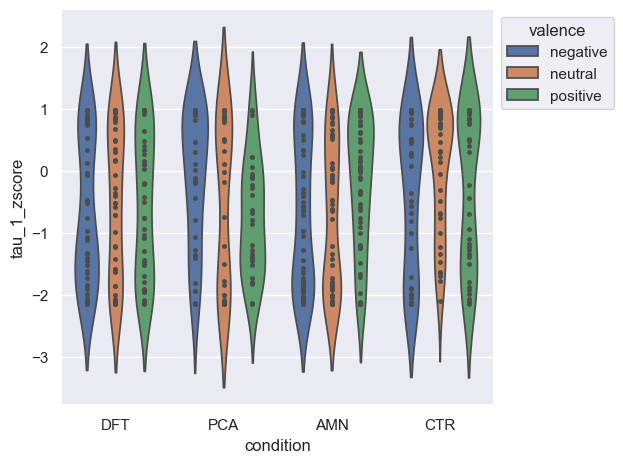

In [131]:
sns.set_theme()

ax = sns.violinplot(
    data=RDX,
    x="condition", y="tau_1_zscore",
    hue="valence",
    inner="point",
    gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

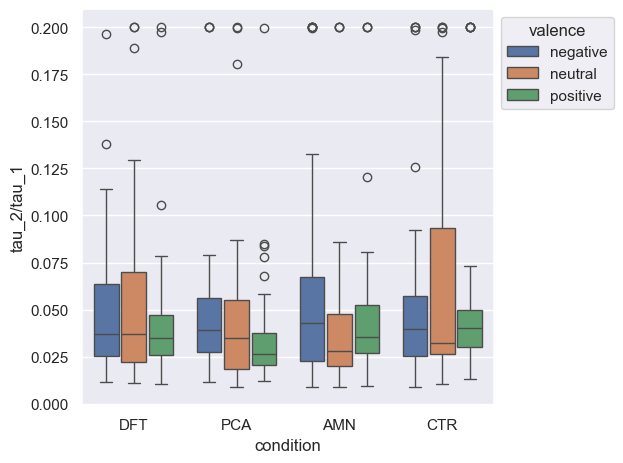

In [133]:
ax = sns.boxplot(
    data=RDX,
    x="condition", y="tau_2/tau_1",
    hue="valence",
    gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

negative vs. neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:2.435e-01 U_stat=4.960e+02
neutral vs. positive: Mann-Whitney-Wilcoxon test two-sided, P_val:4.648e-01 U_stat=4.680e+02
negative vs. positive: Mann-Whitney-Wilcoxon test two-sided, P_val:2.414e-02 U_stat=5.660e+02


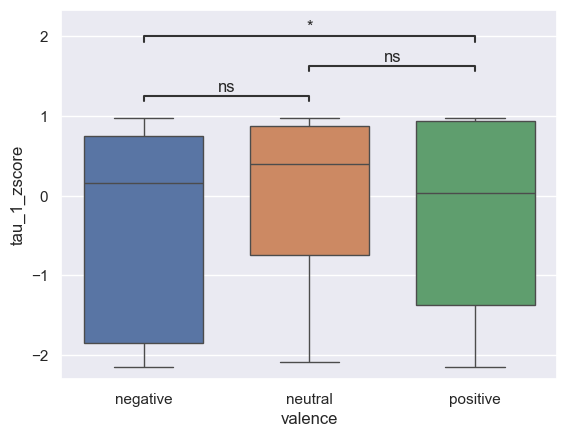

In [164]:
# %pip install statannotations
# Plot singular conditions

## possible tests: t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal, Brunner-Munzel.

from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator
from itertools import combinations

ax = sns.boxplot(
    data=RDX.loc[RDX.loc[:, 'condition']=='CTR'],
    x='valence', y="tau_1_zscore",
    hue="valence",
    gap=.1
)

conds = ['negative', 'neutral', 'positive']
pairs = list(combinations(conds, r=2))

annotator = Annotator(ax, pairs, data=RDX.loc[RDX.loc[:, 'condition']=='PCA'], x='valence', y="tau_1_zscore", hue="valence")
annotator.configure(test="Mann-Whitney")
annotator.apply_and_annotate()
plt.show()

In [205]:
# Plot all conditions

def plot_all_conditions(data, param, x, hue, test):
    plotting_parameters = {
        'data': data,
        'x': x,
        'y': param,
        'hue': hue,
    }
    
    ax = sns.boxplot(**plotting_parameters, gap=.1)

    cond = np.unique(data.loc[:, 'condition'])
    val = np.unique(data.loc[:, 'valence'])
    
    pair = []
    for i in cond:
        if len(val) == 1:
            pair.append(i)
        else:
            for j in val:
                pair.append((i, j))
    pairs = list(combinations(pair, r=2))
    
    annotator = Annotator(ax, pairs=pairs, **plotting_parameters)
    annotator.configure(test=test, hide_non_significant=True).apply_and_annotate()

    try:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    except ValueError:
        pass
    plt.tight_layout()
    plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AMN_neutral vs. AMN_positive: Mann-Whitney-Wilcoxon test two-sided, P_val:2.939e-02 U_stat=1.103e+03
PCA_negative vs. PCA_positive: Mann-Whitney-Wilcoxon test two-sided, P_val:2.414e-02 U_stat=5.660e+02
AMN_neutral vs. CTR_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:2.551e-03 U_stat=6.450e+02
PCA_positive vs. AMN_positive: Mann-Whitney-Wilcoxon test two-sided, P_val:1.630e-02 U_stat=5.310e+02
DFT_negative vs. PCA_negative: Mann-Whitney-Wilcoxon test two-sided, P_val:3.985e-02 U_stat=5.000e+02
AMN_negative vs. CTR_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:2.721e-02 U_stat=7.470e+02
PCA_negative vs. AMN_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:2.573e-02 U_stat=1.017e+03
PCA_positive vs. CTR_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:3.682e-03 U_stat=3.210e+0

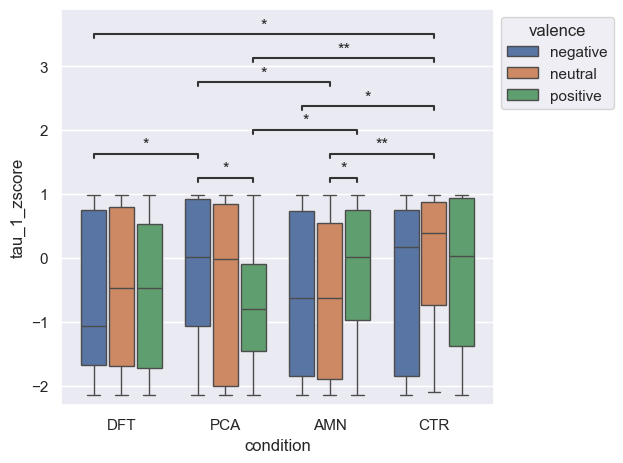

In [206]:
plot_all_conditions(RDX, param='tau_1_zscore', x="condition", hue="valence", test="Mann-Whitney")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AMN_neutral vs. CTR_negative: Mann-Whitney-Wilcoxon test two-sided, P_val:4.526e-02 U_stat=7.730e+02
AMN_neutral vs. CTR_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:2.891e-02 U_stat=7.500e+02
PCA_positive vs. CTR_negative: Mann-Whitney-Wilcoxon test two-sided, P_val:3.975e-02 U_stat=3.880e+02
DFT_negative vs. PCA_positive: Mann-Whitney-Wilcoxon test two-sided, P_val:4.635e-02 U_stat=8.860e+02
PCA_positive vs. CTR_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:2.023e-02 U_stat=3.670e+02
PCA_positive vs. CTR_positive: Mann-Whitney-Wilcoxon test two-sided, P_val:2.312e-02 U_stat=3.710e+02
DFT_negative vs. AMN_neutral: Mann-Whitney-Wilcoxon test two-sided, P_val:4.683e-02 U_stat=1.593e+03


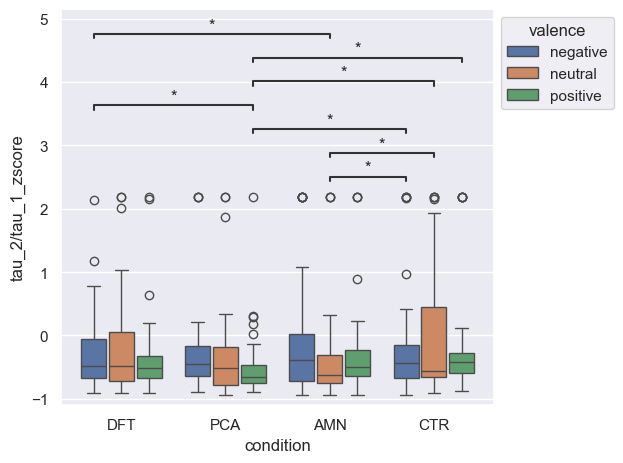

In [207]:
plot_all_conditions(RDX, param='tau_2/tau_1_zscore', x="condition", hue="valence", test="Mann-Whitney")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PCA vs. AMN: Welch's t-test independent samples, P_val:1.752e-02 t=-2.439e+00


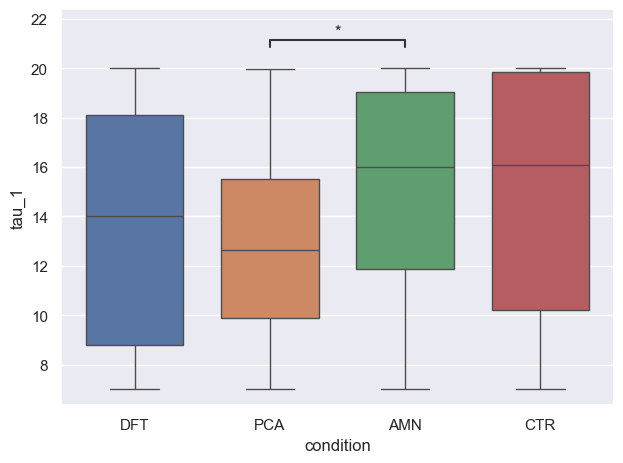

In [215]:
plot_all_conditions(RDX.loc[RDX.loc[:, 'valence']=='positive'], param='tau_1', x='condition', hue='condition', test="t-test_welch")